In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
file = "ISO-NE\ISO-NE\selected_data_ISONE.csv"
df = pd.read_csv(file)

# Exploratory Data Analysis

In [3]:
print("--- First 5 Rows of the DataFrame ---")
print(df.head())
print("\n" + "="*100 + "\n")

print("--- DataFrame Info (Data Types and Non-Null Counts) ---")
df.info()
print("\n" + "="*100 + "\n")

print("--- Count of Missing Values per Column ---")
print(df.isnull().sum())
print("\n" + "="*100 + "\n")

print("--- Summary Statistics for Numerical Columns ---")
print(df.describe())

--- First 5 Rows of the DataFrame ---
         date  year  month  day  weekday  hour   demand  temperature
0  01/03/2003  2003      3    1        7     1  12863.0           23
1  01/03/2003  2003      3    1        7     2  12389.0           22
2  01/03/2003  2003      3    1        7     3  12155.0           21
3  01/03/2003  2003      3    1        7     4  12072.0           21
4  01/03/2003  2003      3    1        7     5  12160.0           22


--- DataFrame Info (Data Types and Non-Null Counts) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103776 entries, 0 to 103775
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         103776 non-null  object 
 1   year         103776 non-null  int64  
 2   month        103776 non-null  int64  
 3   day          103776 non-null  int64  
 4   weekday      103776 non-null  int64  
 5   hour         103776 non-null  int64  
 6   demand       103776 non-null  f

In [4]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)


In [5]:
print("--- Data type of 'date' column after correction ---")
print(df.dtypes)


--- Data type of 'date' column after correction ---
date           datetime64[ns]
year                    int64
month                   int64
day                     int64
weekday                 int64
hour                    int64
demand                float64
temperature             int64
dtype: object


In [6]:
# Check the first few rows to see the result
print("\n--- First 5 rows ---")
print(df.head())


--- First 5 rows ---
        date  year  month  day  weekday  hour   demand  temperature
0 2003-03-01  2003      3    1        7     1  12863.0           23
1 2003-03-01  2003      3    1        7     2  12389.0           22
2 2003-03-01  2003      3    1        7     3  12155.0           21
3 2003-03-01  2003      3    1        7     4  12072.0           21
4 2003-03-01  2003      3    1        7     5  12160.0           22


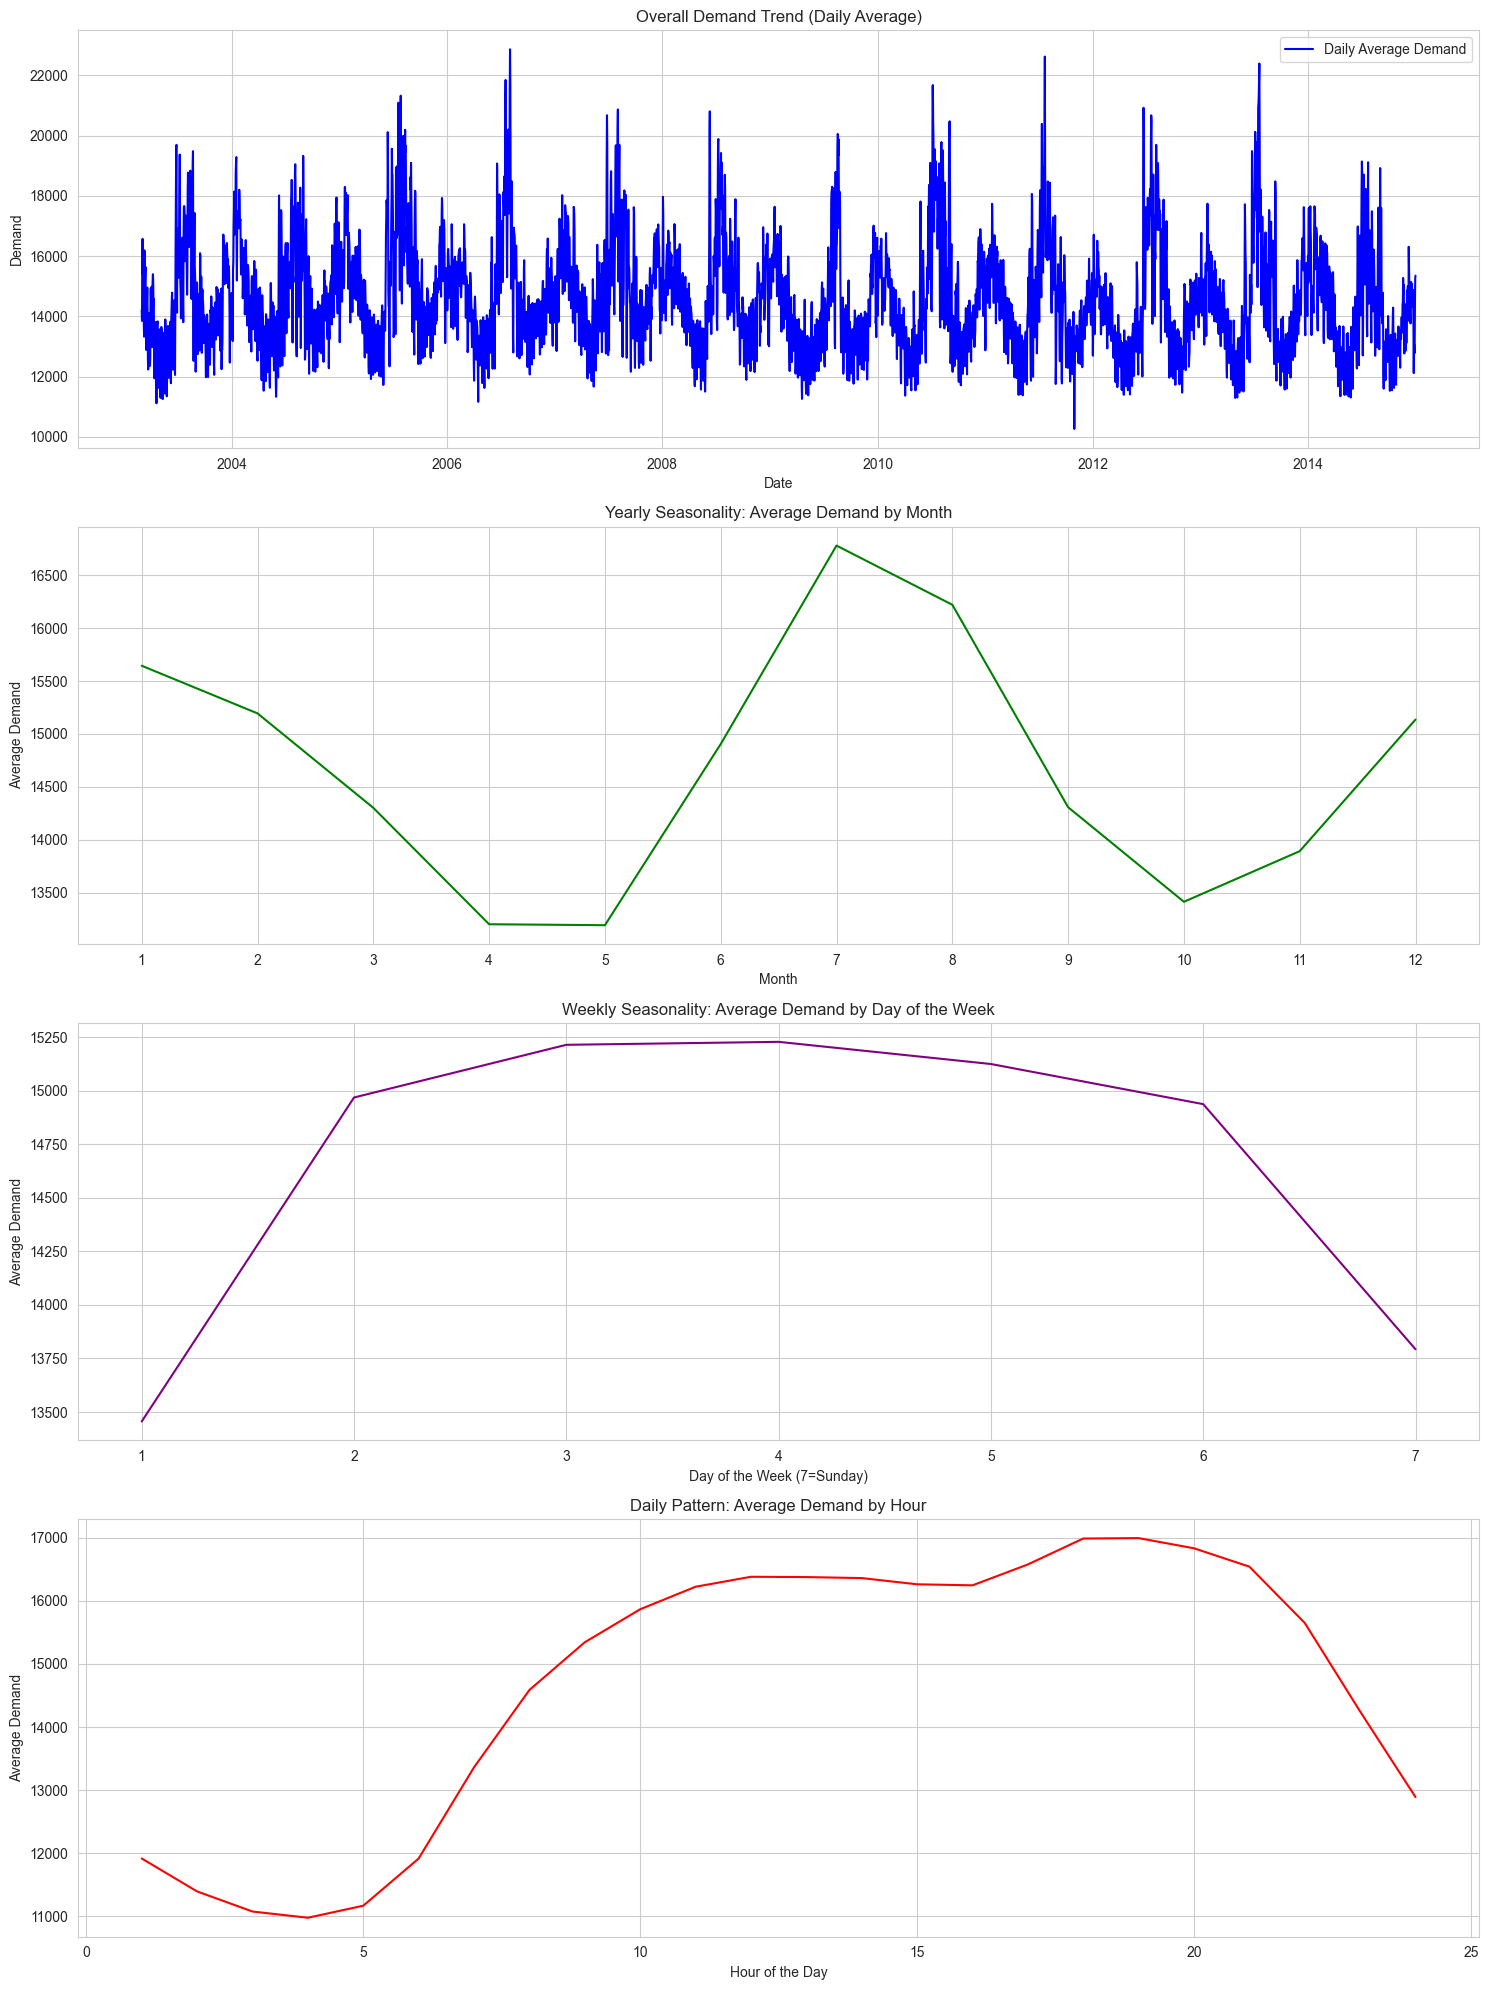

In [7]:
# Set the 'date' column as the index of the DataFrame
# This is very useful for time-series analysis and plotting.
df.set_index('date', inplace=True)

# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# --- 1. Overall Trend ---
# Plot the demand over the entire time period. We'll resample to daily average for a clearer view.
axes[0].plot(df['demand'].resample('D').mean(), label='Daily Average Demand', color='blue')
axes[0].set_title('Overall Demand Trend (Daily Average)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Demand')
axes[0].legend()

# --- 2. Yearly Seasonality (Monthly Pattern) ---
sns.lineplot(x='month', y='demand', data=df, ax=axes[1], errorbar=None, color='green')
axes[1].set_title('Yearly Seasonality: Average Demand by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Demand')
axes[1].set_xticks(range(1, 13)) # Ensure all 12 months are on the x-axis

# --- 3. Weekly Seasonality ---
sns.lineplot(x='weekday', y='demand', data=df, ax=axes[2], errorbar=None, color='purple')
axes[2].set_title('Weekly Seasonality: Average Demand by Day of the Week')
axes[2].set_xlabel('Day of the Week (7=Sunday)')
axes[2].set_ylabel('Average Demand')

# --- 4. Daily (Intraday) Pattern ---
sns.lineplot(x='hour', y='demand', data=df, ax=axes[3], errorbar=None, color='red')
axes[3].set_title('Daily Pattern: Average Demand by Hour')
axes[3].set_xlabel('Hour of the Day')
axes[3].set_ylabel('Average Demand')

# Adjust layout to prevent plots from overlapping
plt.tight_layout()
plt.show()

# <font color = "Green"> Interpretation of the above graphs:</font>

## <font color="Yellow"> Yearly Seasonality </font> 
This plot illustrates how demand changes with the seasons throughout the year.
- Summer Peak: There is a massive peak in electricity demand during the summer, specifically in July (Month 7). This is almost certainly due to the high use of air conditioning to combat hot weather.

- Spring/Autumn Lows: The demand is lowest in the spring months of April and May (Months 4-5) and again in the autumn around October (Month 10). During these periods, the weather is milder, reducing the need for both heating and cooling.

- Winter Shoulder: Demand is moderately high during the winter months, suggesting energy use for heating, but it is not as extreme as the summer air conditioning peak.

## <font color="Yellow"> Weekly Seasonality </font> 
This graph highlights the clear difference in electricity usage between weekdays and weekends.

- Weekday Plateau: Demand jumps up significantly on Day 2 (Tuesday) and stays consistently high from Tuesday through Friday (Days 2-5). This reflects the higher energy consumption from commercial and industrial activities during the work week.

- Weekend Drop: Demand is noticeably lower on the weekends. It begins to drop on Day 6 (Saturday) and hits its lowest point of the week on Day 7 (Sunday), when most businesses are closed. Day 1 (Monday) also appears slightly lower than the rest of the weekdays, which can sometimes happen.

## <font color="Yellow"> Daily Seasonality </font> 
This plot shows the typical electricity consumption rhythm over a 24-hour period.
- Overnight Low: Demand is at its lowest in the very early morning, hitting a bottom around 4-5 AM when most people are asleep and business activity is minimal.

- Morning Ramp-Up: Starting around 6 AM, demand begins to rise sharply as the day starts, people wake up, and businesses open.

- Daytime Plateau & Evening Peak: Demand remains high throughout the day and into the evening. It reaches its absolute peak around 7-8 PM (hour 19-20), likely driven by residential use (lighting, cooking, entertainment) after the workday.

- Nightly Drop: After the evening peak, demand falls off steeply as people go to bed.

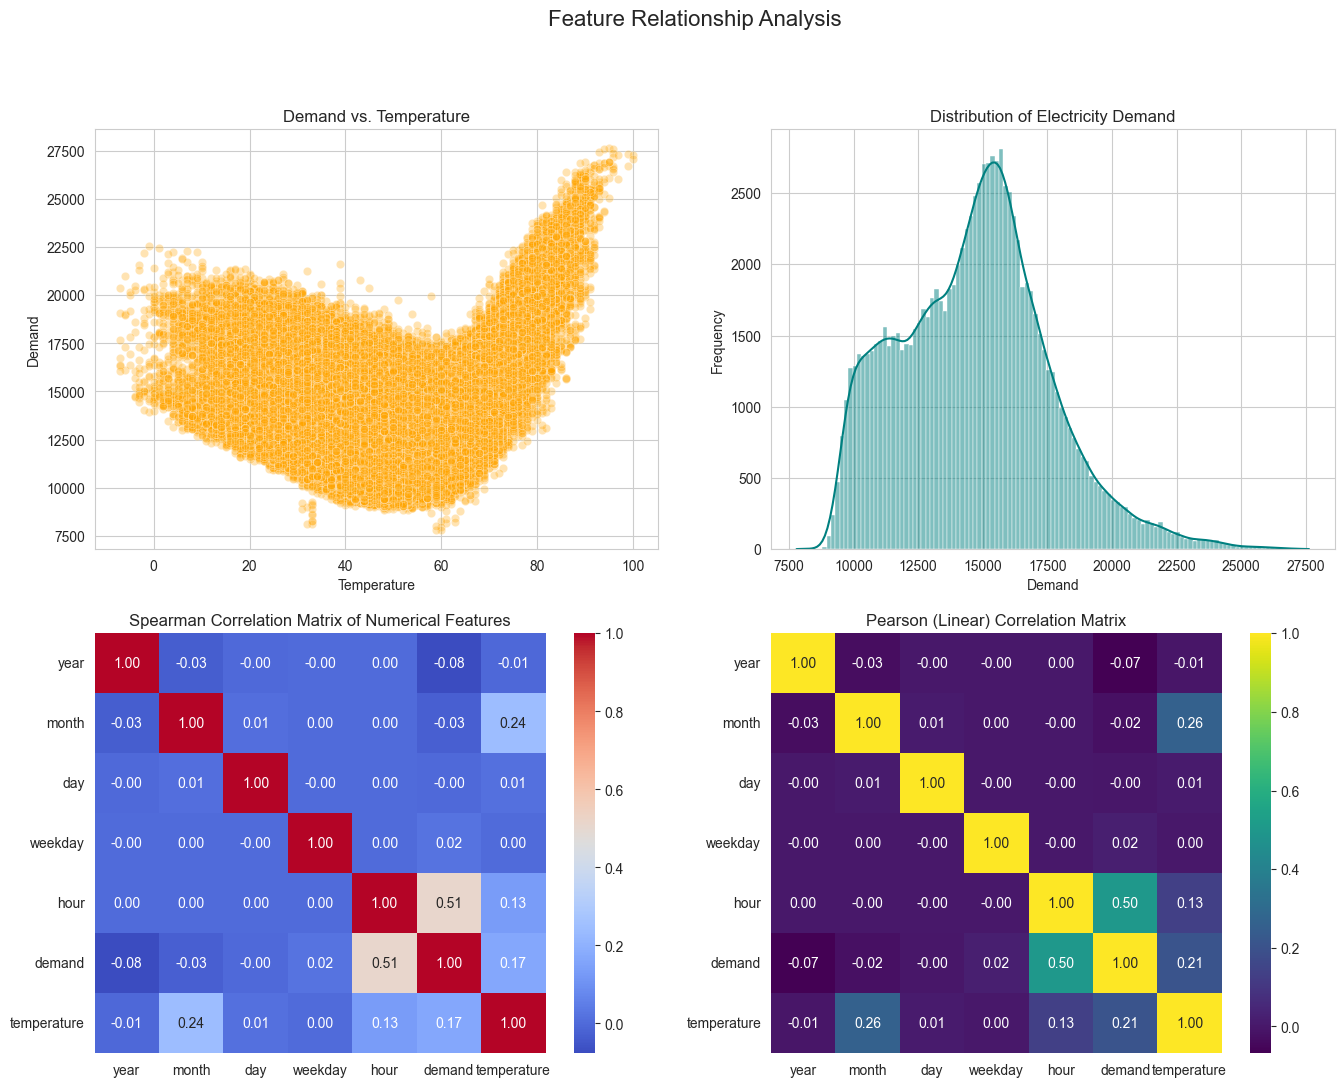

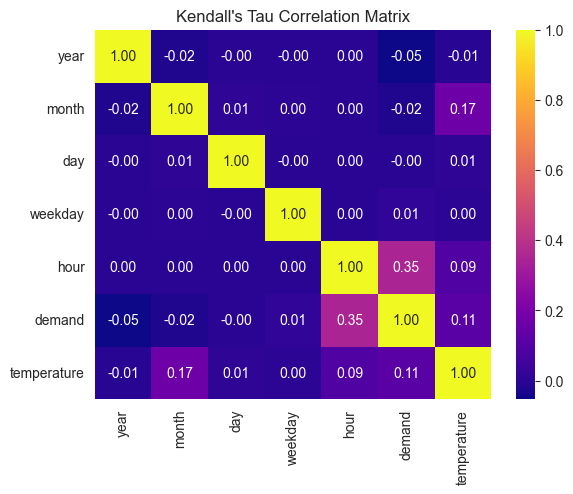

<Figure size 640x480 with 0 Axes>

In [14]:
# Reset index to use 'date' and other columns easily in seaborn plots
# This undoes the set_index from the previous step, which is fine for these plots.
# df.reset_index(inplace=True)

# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Relationship Analysis', fontsize=16)

# --- 1. Demand vs. Temperature ---
sns.scatterplot(x='temperature', y='demand', data=df, ax=axes[0, 0], alpha=0.3, color='orange')
axes[0, 0].set_title('Demand vs. Temperature')
axes[0, 0].set_xlabel('Temperature')
axes[0, 0].set_ylabel('Demand')

# --- 2. Distribution of Demand ---
sns.histplot(df['demand'], kde=True, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Distribution of Electricity Demand')
axes[0, 1].set_xlabel('Demand')
axes[0, 1].set_ylabel('Frequency')

# --- 3. Correlation Heatmap (using Spearman) ---

# Select only the numerical columns for the correlation matrix
numerical_cols = ['year', 'month', 'day', 'weekday', 'hour', 'demand', 'temperature']

# Calculate the Spearman correlation matrix by adding method='spearman'
corr_matrix = df[numerical_cols].corr(method='spearman')

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Spearman Correlation Matrix of Numerical Features')

# --- Pearson Correlation Heatmap ---

# Calculate the Pearson correlation matrix (the default method)
pearson_corr_matrix = df[numerical_cols].corr(method='pearson')

# Plot the heatmap
sns.heatmap(pearson_corr_matrix, annot=True, fmt='.2f', cmap='viridis')
plt.title('Pearson (Linear) Correlation Matrix')
plt.show()


# --- Kendall's Tau Correlation Heatmap ---

# Calculate the Kendall's Tau correlation matrix
kendall_corr_matrix = df[numerical_cols].corr(method='kendall')

# Plot the heatmap
sns.heatmap(kendall_corr_matrix, annot=True, fmt='.2f', cmap='plasma')
plt.title("Kendall's Tau Correlation Matrix")
plt.show()


# Hide the empty subplot
axes[1, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 1. Demand vs. Temperature (Scatter Plot)

This plot reveals a very clear and strong **non-linear relationship** between temperature and electricity demand.

* **"U" Shape:** The data points form a distinct "U" shape. This indicates that demand is high at both very low and very high temperatures.
* **Interpretation:**
    * At **low temperatures** (left side), demand is high due to the need for **heating**.
    * At **high temperatures** (right side), demand is high due to the need for **air conditioning**.
    * The lowest demand occurs at a moderate "base" temperature where neither heating nor cooling is required.

This pattern confirms that temperature is a critical predictor of demand, but the relationship isn't a simple straight line.

---

### 2. Distribution of Electricity Demand (Histogram)

This plot shows the frequency of different demand values in your dataset.

* **Main Peak:** The distribution has a single peak, showing that the most common demand values are clustered around 16,000-17,000.
* **Left Skew (Negative Skew):** The curve is not perfectly symmetrical; it has a longer tail on the left side. This means that while the most frequent demand is high, there are a significant number of instances with lower demand values, but very few instances with extremely high demand values far beyond the peak.

---

### 3. Spearman Correlation Matrix (Heatmap)

This heatmap quantifies the monotonic relationships between your numerical features. Red indicates a positive correlation, and blue indicates a negative one.

* **`demand` vs. `hour` (0.51):** This is the strongest correlation with `demand`. It's a moderate positive relationship, confirming that demand tends to rise as the hour progresses into peak times of the day.
* **`demand` vs. `temperature` (0.17):** This value is surprisingly low, and it highlights a very important concept. The scatter plot shows a *strong* relationship, but because it's a "U" shape and not a straight line (non-monotonic), the Spearman correlation coefficient is weak. This is a perfect example of why visualizing data is crucial; the correlation number alone is misleading.
* **Other Features:** The rest of the features (`year`, `month`, `day`, `weekday`) show very little to no monotonic correlation with `demand`.

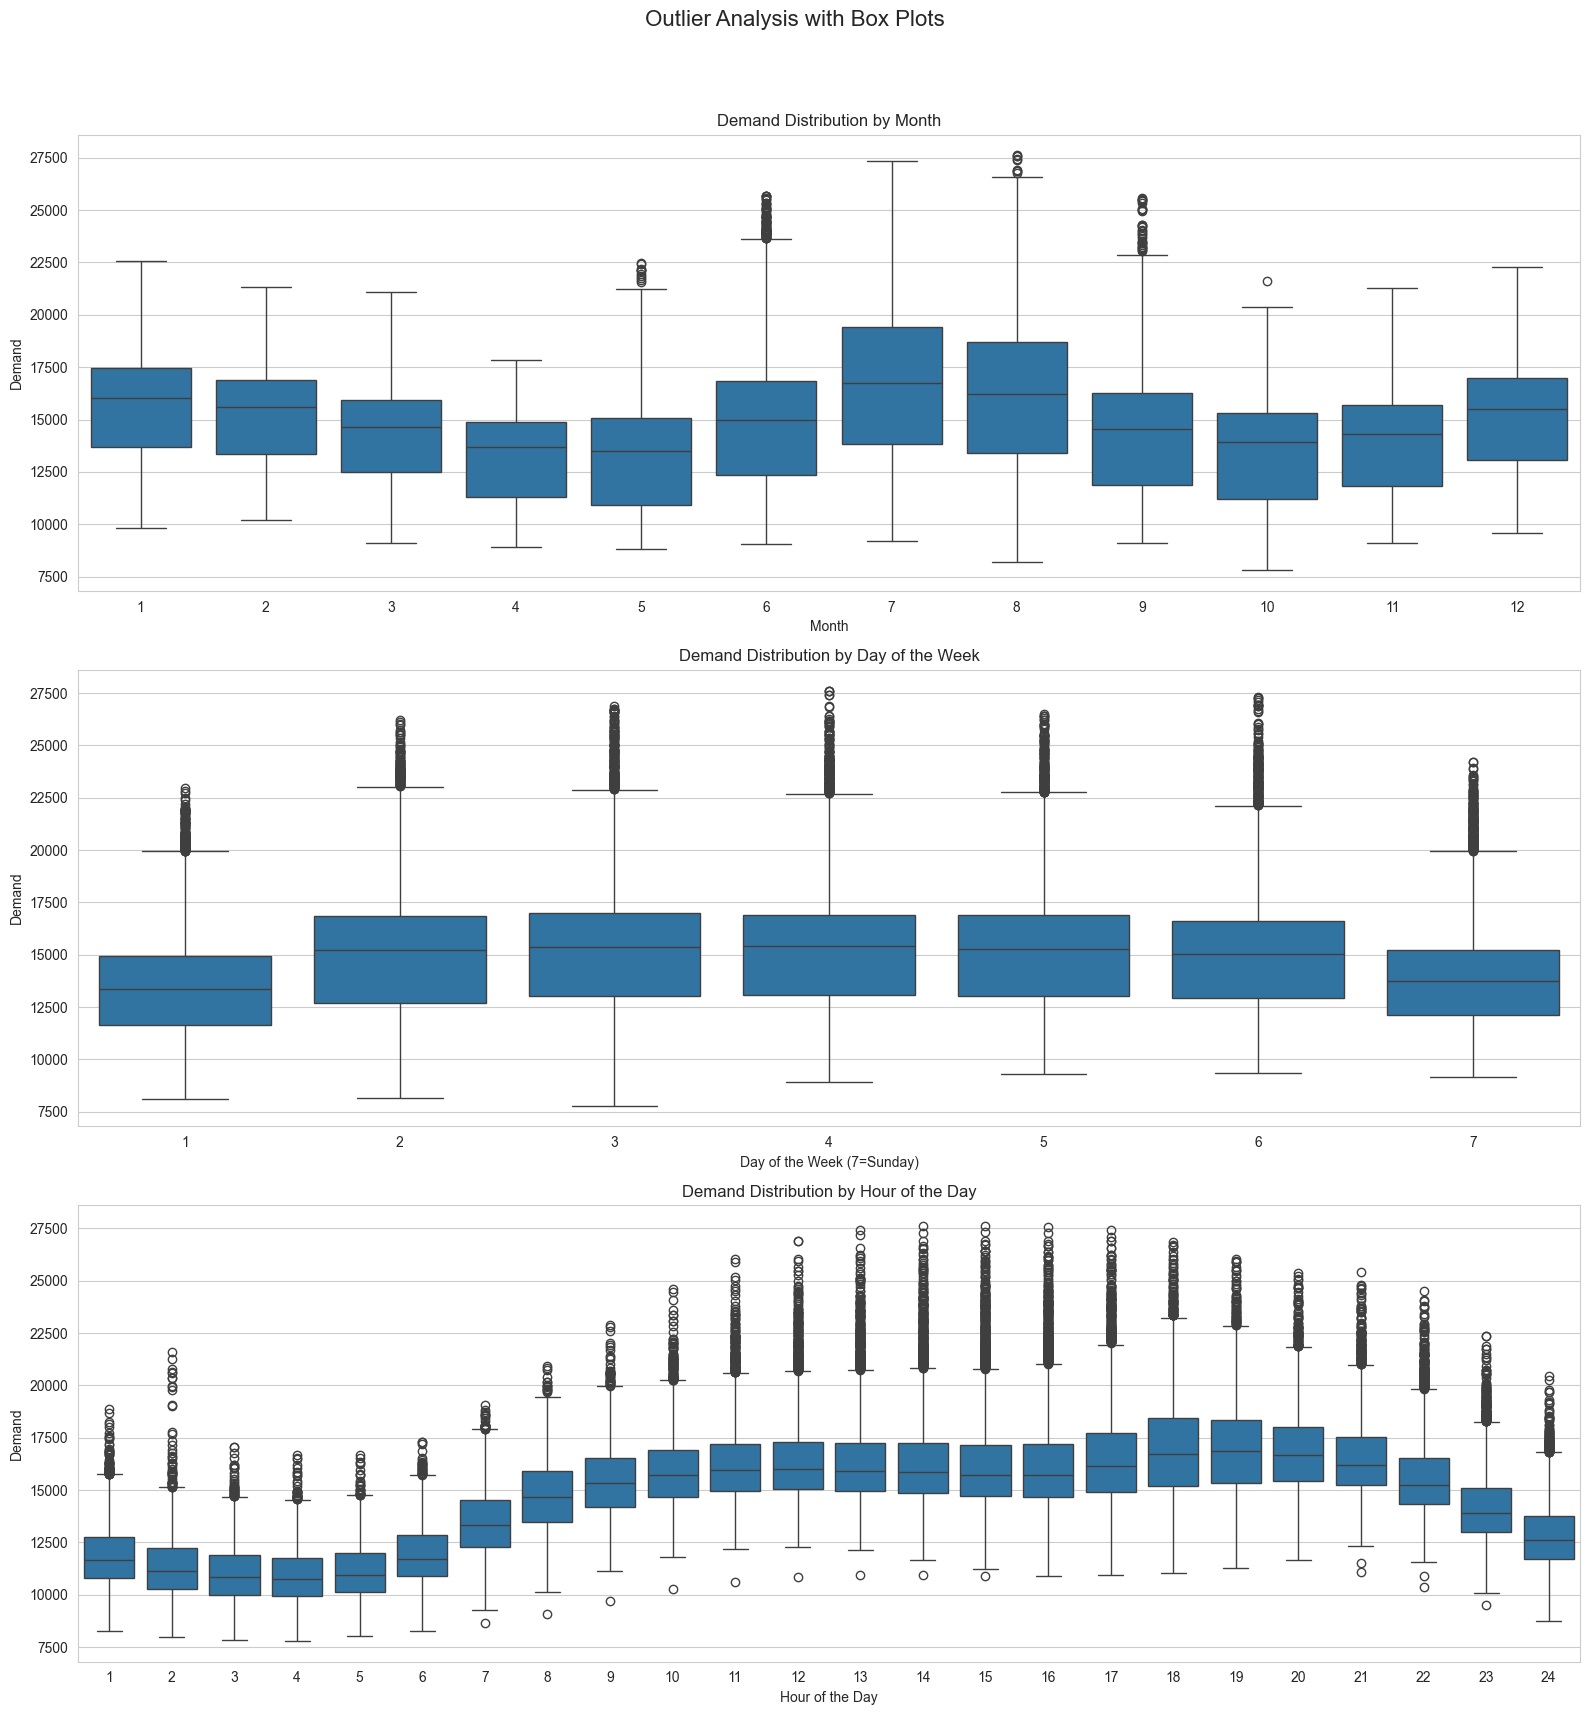

In [9]:
# We are using the dataframe 'df' from the previous steps.
# If you didn't run the last step, make sure the index is reset:
# df.reset_index(inplace=True)

# Set the plot style
sns.set_style("whitegrid")

# Create a figure for our plots
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Outlier Analysis with Box Plots', fontsize=16)

# --- 1. Box Plot of Demand by Month ---
sns.boxplot(x='month', y='demand', data=df, ax=axes[0])
axes[0].set_title('Demand Distribution by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Demand')

# --- 2. Box Plot of Demand by Weekday ---
sns.boxplot(x='weekday', y='demand', data=df, ax=axes[1])
axes[1].set_title('Demand Distribution by Day of the Week')
axes[1].set_xlabel('Day of the Week (7=Sunday)')
axes[1].set_ylabel('Demand')

# --- 3. Box Plot of Demand by Hour ---
sns.boxplot(x='hour', y='demand', data=df, ax=axes[2])
axes[2].set_title('Demand Distribution by Hour of the Day')
axes[2].set_xlabel('Hour of the Day')
axes[2].set_ylabel('Demand')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()